# Logistic Regression - Model Evaluation

Evaluación de modelos de Regresión Logística (BALANCED vs RAW).

## 1. Imports

In [1]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_fscore_support, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
print("✓ Libraries imported")

✓ Libraries imported


## 2. Load Data and Models

In [2]:
BASE_PATH = Path('../../..').resolve()
DATA_PATH = BASE_PATH / 'data' / 'processed' / 'pickle'
MODELS_PATH = BASE_PATH / 'models' / 'logistic_regression'
RESULTS_PATH = BASE_PATH / 'data' / 'results' / 'logistic_regression'
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

# CARGAMOS X_train y y_train (datos reales sin alterar) PARA EL CROSS VALIDATION
with open(DATA_PATH / 'X_train_raw.pkl', 'rb') as f:
    X_train_raw = pickle.load(f)
with open(DATA_PATH / 'y_train_raw.pkl', 'rb') as f:
    y_train_raw = pickle.load(f)

if isinstance(X_train_raw, pd.DataFrame):
    X_train_raw = X_train_raw.values
if isinstance(y_train_raw, pd.DataFrame):
    y_train_raw = y_train_raw.iloc[:, 0]

y_test = y_train_raw

# Load models (Solo para extraer sus hiperparámetros)
with open(MODELS_PATH / 'modelo_logistic_regression_balanced.pkl', 'rb') as f:
    model_balanced = pickle.load(f)
with open(MODELS_PATH / 'modelo_logistic_regression_raw.pkl', 'rb') as f:
    model_raw = pickle.load(f)

print(f"✓ Data for CV loaded: shape     : {X_train_raw.shape}")
print(f"✓ Class distribution : {dict(pd.Series(y_train_raw).value_counts().sort_index())}")
print(f"✓ Models loaded")

✓ Data for CV loaded: shape     : (699, 651)
✓ Class distribution : {0: np.int64(633), 1: np.int64(66)}
✓ Models loaded


## 3. Generate Predictions

In [3]:
print("Generando predicciones Out-of-Fold usando 5-Fold Stratified CV para Logistic Regression...\n")

# Extraemos parámetros (solo los relevantes para LR)
TRACKED_PARAMS = ['C', 'penalty', 'solver', 'max_iter', 'class_weight', 'l1_ratio']
params_balanced = {k: v for k, v in model_balanced.get_params().items() if k in TRACKED_PARAMS and v is not None}
params_raw   = {k: v for k, v in model_raw.get_params().items()   if k in TRACKED_PARAMS and v is not None}

if 'class_weight' not in params_raw or params_raw['class_weight'] is None:
    params_raw['class_weight'] = 'balanced'

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 1. PREDICCIONES CV MODELO RAW ---
cv_model_raw = LogisticRegression(random_state=42, **params_raw)
print("  Calculando predicciones CV para RAW...")
y_pred_raw = cross_val_predict(cv_model_raw, X_train_raw, y_train_raw, cv=outer_cv, method='predict', n_jobs=-1)
y_proba_raw = cross_val_predict(cv_model_raw, X_train_raw, y_train_raw, cv=outer_cv, method='predict_proba', n_jobs=-1)

# --- 2. PREDICCIONES CV MODELO ADASYN (PIPELINE) ---
# Aseguramos que el BALANCED no lleve class_weight='balanced' para no re-pesar sus clases
if 'class_weight' in params_balanced:
    params_balanced['class_weight'] = None

cv_model_adasyn = LogisticRegression(random_state=42, **params_balanced)
adasyn_cv = ADASYN(sampling_strategy='auto', random_state=42, n_neighbors=5)
pipeline = ImbPipeline([('adasyn', adasyn_cv), ('lr', cv_model_adasyn)])

print("  Calculando predicciones CV para ADASYN (Pipeline)...")
y_pred_balanced = cross_val_predict(pipeline, X_train_raw, y_train_raw, cv=outer_cv, method='predict', n_jobs=-1)
y_proba_balanced = cross_val_predict(pipeline, X_train_raw, y_train_raw, cv=outer_cv, method='predict_proba', n_jobs=-1)

print("\n✓ Predicciones CV finalizadas. \nAhora el resto del notebook calculará TODAS las métricas sobre estos resultados realistas.")

Generando predicciones Out-of-Fold usando 5-Fold Stratified CV para Logistic Regression...

  Calculando predicciones CV para RAW...


  Calculando predicciones CV para ADASYN (Pipeline)...

✓ Predicciones CV finalizadas. 
Ahora el resto del notebook calculará TODAS las métricas sobre estos resultados realistas.


## 4. Overall Metrics

In [4]:
print("" + "="*70)
print("OVERALL MODEL METRICS")
print("="*70)

overall_metrics = {
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)',
               'F1-Score (macro)', "Cohen's Kappa"],
    'BALANCED': [
        f"{accuracy_score(y_test, y_pred_balanced):.4f}",
        f"{precision_score(y_test, y_pred_balanced, average='macro', zero_division=0):.4f}",
        f"{recall_score(y_test, y_pred_balanced, average='macro', zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred_balanced, average='macro', zero_division=0):.4f}",
        f"{cohen_kappa_score(y_test, y_pred_balanced):.4f}",
    ],
    'RAW': [
        f"{accuracy_score(y_test, y_pred_raw):.4f}",
        f"{precision_score(y_test, y_pred_raw, average='macro', zero_division=0):.4f}",
        f"{recall_score(y_test, y_pred_raw, average='macro', zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred_raw, average='macro', zero_division=0):.4f}",
        f"{cohen_kappa_score(y_test, y_pred_raw):.4f}",
    ]
}

df_overall = pd.DataFrame(overall_metrics)
print("" + df_overall.to_string(index=False))

OVERALL MODEL METRICS
           Metric BALANCED    RAW
         Accuracy   0.8641 0.8541
Precision (macro)   0.6121 0.6180
   Recall (macro)   0.6196 0.6548
 F1-Score (macro)   0.6156 0.6320
    Cohen's Kappa   0.2313 0.2662


### 4.1 Overall Metrics - Visualization

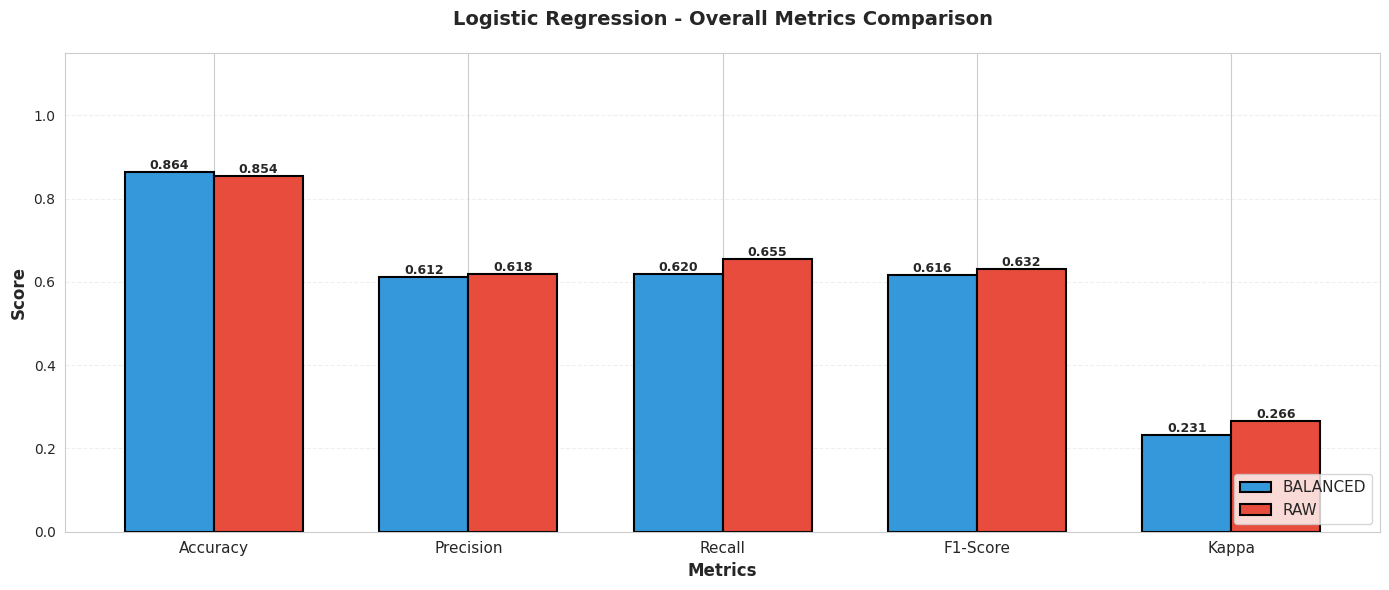

✓ Plot saved


In [ ]:
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', "Kappa"]
balanced_vals = [float(x) for x in df_overall['BALANCED'].values]
raw_vals   = [float(x) for x in df_overall['RAW'].values]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, balanced_vals, width, label='BALANCED', color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, raw_vals,   width, label='RAW',   color='#e74c3c', edgecolor='black', linewidth=1.5)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Logistic Regression - Overall Metrics Comparison', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.15])
plt.tight_layout()
plt.show()
print("✓ Plot saved")

## 5. Per-Class Metrics

In [6]:
prec_s, rec_s, f1_s, sup_s = precision_recall_fscore_support(y_test, y_pred_balanced, average=None)
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
sensitivity_s, specificity_s = [], []
for i in range(2):
    tp = cm_balanced[i, i]; fn = cm_balanced[i, :].sum() - tp
    fp = cm_balanced[:, i].sum() - tp; tn = cm_balanced.sum() - (tp + fn + fp)
    sensitivity_s.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    specificity_s.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

df_class_balanced = pd.DataFrame({
    'Class': [0,1], 'Precision': prec_s, 'Recall': rec_s, 'F1-Score': f1_s,
    'Sensitivity': sensitivity_s, 'Specificity': specificity_s, 'Support': sup_s
})

prec_r, rec_r, f1_r, sup_r = precision_recall_fscore_support(y_test, y_pred_raw, average=None)
cm_raw = confusion_matrix(y_test, y_pred_raw)
sensitivity_r, specificity_r = [], []
for i in range(2):
    tp = cm_raw[i, i]; fn = cm_raw[i, :].sum() - tp
    fp = cm_raw[:, i].sum() - tp; tn = cm_raw.sum() - (tp + fn + fp)
    sensitivity_r.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    specificity_r.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

df_class_raw = pd.DataFrame({
    'Class': [0,1], 'Precision': prec_r, 'Recall': rec_r, 'F1-Score': f1_r,
    'Sensitivity': sensitivity_r, 'Specificity': specificity_r, 'Support': sup_r
})

print("" + "="*70)
print("PER-CLASS METRICS - BALANCED MODEL")
print("="*70)
print("" + df_class_balanced.to_string(index=False))
print("" + "="*70)
print("PER-CLASS METRICS - RAW MODEL")
print("="*70)
print("" + df_class_raw.to_string(index=False))

PER-CLASS METRICS - BALANCED MODEL
 Class  Precision   Recall  F1-Score  Sensitivity  Specificity  Support
     0   0.928344 0.921011  0.924663     0.921011     0.318182      633
     1   0.295775 0.318182  0.306569     0.318182     0.921011       66
PER-CLASS METRICS - RAW MODEL
 Class  Precision   Recall  F1-Score  Sensitivity  Specificity  Support
     0   0.935961 0.900474  0.917874     0.900474     0.409091      633
     1   0.300000 0.409091  0.346154     0.409091     0.900474       66


### 5.1 Per-Class Metrics - Visualization

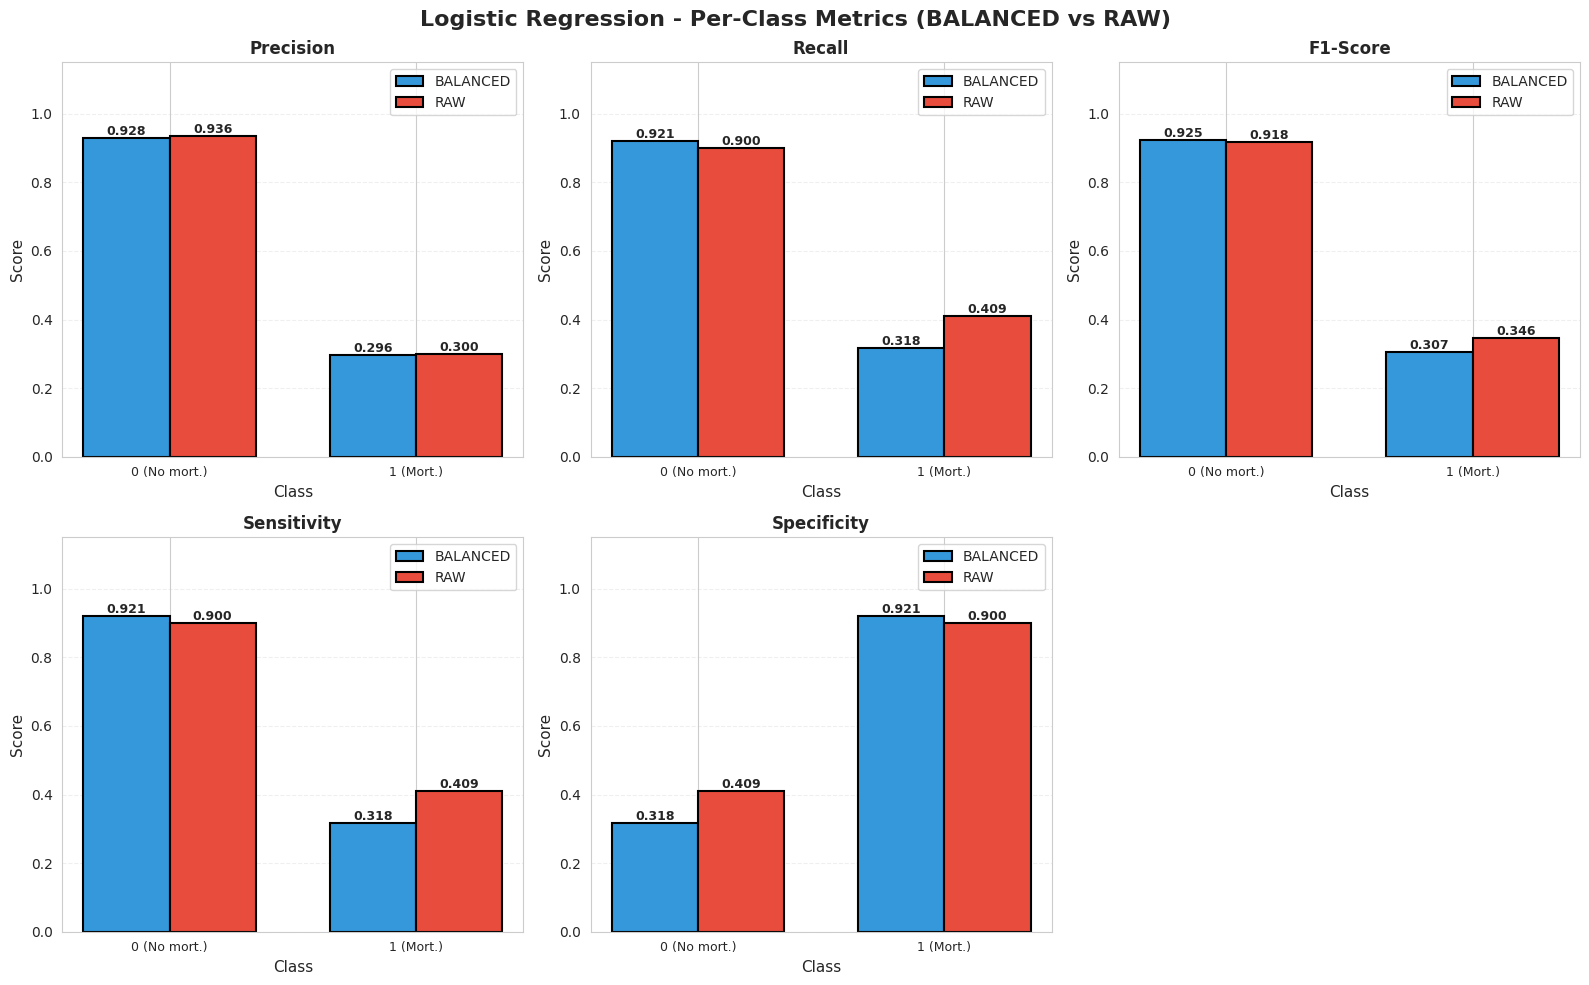

✓ Plot saved


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Logistic Regression - Per-Class Metrics (BALANCED vs RAW)', fontsize=16, fontweight='bold')

data_map = {
    'Precision':   (prec_s, prec_r),
    'Recall':      (rec_s, rec_r),
    'F1-Score':    (f1_s, f1_r),
    'Sensitivity': (sensitivity_s, sensitivity_r),
    'Specificity': (specificity_s, specificity_r),
}

for idx, (metric, (balanced_data, raw_data)) in enumerate(data_map.items()):
    ax = axes[idx // 3][idx % 3]
    x = np.arange(2); width = 0.35
    bars1 = ax.bar(x - width/2, balanced_data, width, label='BALANCED', color='#3498db', edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, raw_data,   width, label='RAW',   color='#e74c3c', edgecolor='black', linewidth=1.5)
    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.3f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(['0 (No mort.)', '1 (Mort.)'], fontsize=9)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.15])

axes[1, 2].remove()
plt.tight_layout()
plt.show()
print("✓ Plot saved")

## 6. ROC-AUC Analysis

ROC-AUC SCORES (Binary)
BALANCED AUC: 0.7148
RAW   AUC: 0.7213


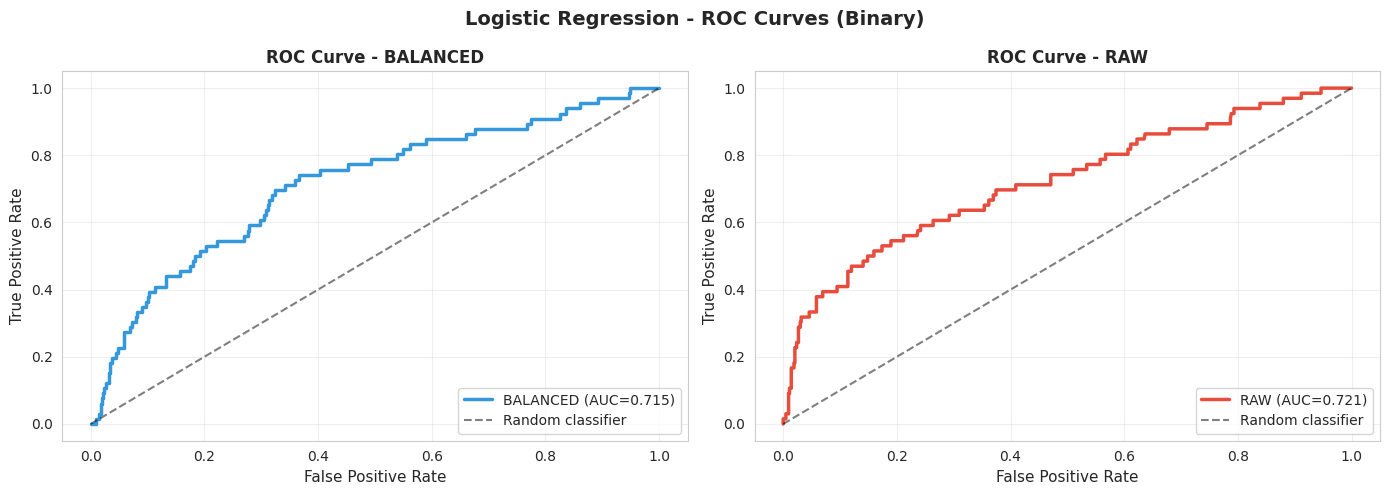

✓ ROC curves saved


In [ ]:
print("" + "="*70)
print("ROC-AUC SCORES (Binary)")
print("="*70)

# Para binario: usar directamente y_proba[:, 1] (prob. de clase "muere")
auc_balanced = roc_auc_score(y_test, y_proba_balanced[:, 1])
auc_raw   = roc_auc_score(y_test, y_proba_raw[:, 1])
print(f"BALANCED AUC: {auc_balanced:.4f}")
print(f"RAW   AUC: {auc_raw:.4f}")

# Una curva ROC por modelo (no por clase)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression - ROC Curves (Binary)', fontsize=14, fontweight='bold')

for ax, y_proba, auc, label, color in zip(
    axes,
    [y_proba_balanced, y_proba_raw],
    [auc_balanced, auc_raw],
    ['BALANCED', 'RAW'],
    ['#3498db', '#e74c3c']
):
    fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{label} (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random classifier')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC Curve - {label}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ ROC curves saved")


## 7. Confusion Matrices

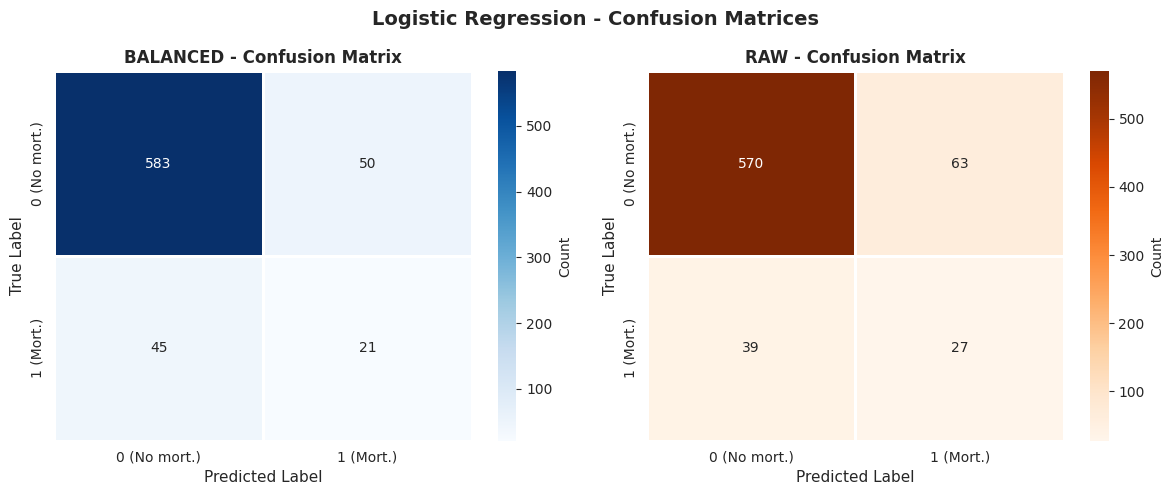

✓ Confusion matrices saved


In [ ]:
class_labels = ['0 (No mort.)', '1 (Mort.)']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Logistic Regression - Confusion Matrices', fontsize=14, fontweight='bold')

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Count'}, linewidths=2)
axes[0].set_title('BALANCED - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Count'}, linewidths=2)
axes[1].set_title('RAW - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()
print("✓ Confusion matrices saved")

## 8. Final Comparison and Recommendation

In [10]:
print("" + "="*70)
print("FINAL COMPARISON")
print("="*70)

print("Class 0 (No Muere):")
print(f"  BALANCED - Recall: {rec_s[0]:.4f} | Sensitivity: {sensitivity_s[0]:.4f} | Specificity: {specificity_s[0]:.4f}")
print(f"  RAW   - Recall: {rec_r[0]:.4f} | Sensitivity: {sensitivity_r[0]:.4f} | Specificity: {specificity_r[0]:.4f}")

print("\nClass 1 (Muere - Critical):")
print(f"  BALANCED - Recall: {rec_s[1]:.4f} | Sensitivity: {sensitivity_s[1]:.4f} | Specificity: {specificity_s[1]:.4f} | AUC: {auc_balanced:.4f}")
print(f"  RAW   - Recall: {rec_r[1]:.4f} | Sensitivity: {sensitivity_r[1]:.4f} | Specificity: {specificity_r[1]:.4f} | AUC: {auc_raw:.4f}")

mean_recall_balanced = np.mean([rec_s[0], rec_s[1]])
mean_recall_raw   = np.mean([rec_r[0], rec_r[1]])
print(f"\nMean Recall (macro): BALANCED={mean_recall_balanced:.4f}  |  RAW={mean_recall_raw:.4f}")
print(f"AUC:                 BALANCED={auc_balanced:.4f}  |  RAW={auc_raw:.4f}")

winner = "BALANCED" if mean_recall_balanced > mean_recall_raw else "RAW"
print(f"\n✅ RECOMMENDATION: {winner} model (higher average recall)")
print("Note: Recall prioritized — detecting mortality is more critical")
print("      than avoiding false alarms in a postoperative risk context.")
print("="*70)

FINAL COMPARISON
Class 0 (No Muere):
  BALANCED - Recall: 0.9210 | Sensitivity: 0.9210 | Specificity: 0.3182
  RAW   - Recall: 0.9005 | Sensitivity: 0.9005 | Specificity: 0.4091

Class 1 (Muere - Critical):
  BALANCED - Recall: 0.3182 | Sensitivity: 0.3182 | Specificity: 0.9210 | AUC: 0.7148
  RAW   - Recall: 0.4091 | Sensitivity: 0.4091 | Specificity: 0.9005 | AUC: 0.7213

Mean Recall (macro): BALANCED=0.6196  |  RAW=0.6548
AUC:                 BALANCED=0.7148  |  RAW=0.7213

✅ RECOMMENDATION: RAW model (higher average recall)
Note: Recall prioritized — detecting mortality is more critical
      than avoiding false alarms in a postoperative risk context.


## 9. Save Results to File

In [11]:
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
results_filename = RESULTS_PATH / f"evaluation_results_{timestamp}.txt"

lr_params_keys = ['C', 'penalty', 'solver', 'max_iter', 'class_weight', 'random_state']
# ↑ quitado 'multi_class' — ya no aplica para binario

params_balanced_filtered = {k: v for k, v in model_balanced.get_params().items() if k in lr_params_keys}
params_raw_filtered   = {k: v for k, v in model_raw.get_params().items()   if k in lr_params_keys}

results_text = f"""
{'='*80}
LOGISTIC REGRESSION MODEL EVALUATION RESULTS (BINARY: muere / no muere)
Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
{'='*80}

0. MODEL HYPERPARAMETERS
{'-'*80}
BALANCED Model Parameters:
{chr(10).join(f"  {k}: {v}" for k, v in params_balanced_filtered.items())}

RAW Model Parameters:
{chr(10).join(f"  {k}: {v}" for k, v in params_raw_filtered.items())}

1. OVERALL MODEL METRICS
{'-'*80}
{df_overall.to_string(index=False)}

2. PER-CLASS METRICS - BALANCED MODEL
{'-'*80}
{df_class_balanced.to_string(index=False)}

3. PER-CLASS METRICS - RAW MODEL
{'-'*80}
{df_class_raw.to_string(index=False)}

4. ROC-AUC SCORES (Binary)
{'-'*80}
BALANCED AUC: {auc_balanced:.4f}
RAW   AUC: {auc_raw:.4f}

5. CONFUSION MATRICES
{'-'*80}
BALANCED:
{cm_balanced}

RAW:
{cm_raw}

6. FINAL COMPARISON
{'-'*80}
Class 0 (No Muere):
  BALANCED - Recall: {rec_s[0]:.4f} | Sensitivity: {sensitivity_s[0]:.4f} | Specificity: {specificity_s[0]:.4f}
  RAW   - Recall: {rec_r[0]:.4f} | Sensitivity: {sensitivity_r[0]:.4f} | Specificity: {specificity_r[0]:.4f}

Class 1 (Muere - Critical):
  BALANCED - Recall: {rec_s[1]:.4f} | Sensitivity: {sensitivity_s[1]:.4f} | Specificity: {specificity_s[1]:.4f} | AUC: {auc_balanced:.4f}
  RAW   - Recall: {rec_r[1]:.4f} | Sensitivity: {sensitivity_r[1]:.4f} | Specificity: {specificity_r[1]:.4f} | AUC: {auc_raw:.4f}

Mean Recall (macro): BALANCED={mean_recall_balanced:.4f}  |  RAW={mean_recall_raw:.4f}
AUC:                 BALANCED={auc_balanced:.4f}  |  RAW={auc_raw:.4f}

7. RECOMMENDATION
{'-'*80}
✅ RECOMMENDED MODEL: {winner.upper()}
   (Higher average recall for mortality prediction)

Note: Recall is prioritized for postoperative mortality risk prediction.
{'='*80}
"""

with open(results_filename, 'w') as f:
    f.write(results_text)

print(f"✓ Results saved → {results_filename.name}")
print(f"✅ Evaluation complete. Check {RESULTS_PATH} for all outputs.")


✓ Results saved → evaluation_results_2026-05-14_13-20-32.txt
✅ Evaluation complete. Check /home/pablo/Desktop/Estressss/pdg/data/results/logistic_regression for all outputs.
